Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Enter a content topic: Generative Artificial Intelligence


  0%|          | 0/50 [00:00<?, ?it/s]


GENERATED TEXT
------------------------------------------------------------
                                                                                         


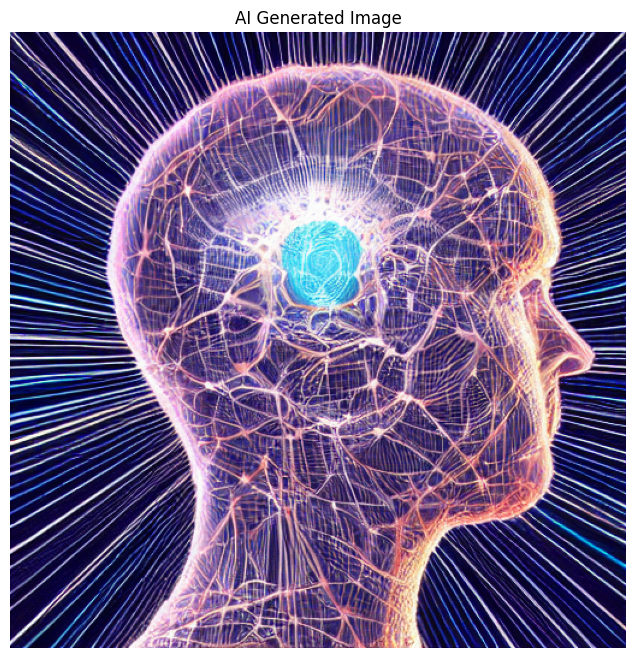


Image saved as generated_content_image.png


In [ ]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from diffusers import StableDiffusionPipeline

tokenizer = AutoTokenizer.from_pretrained(
    "google/flan-t5-base"
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-base"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

image_generator = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

image_generator = image_generator.to(device)

topic = input("Enter a content topic: ")

text_prompt = f"""
Write a short article (120 words) on the topic:
{topic}

Include:
1. Introduction
2. Importance
3. Applications
"""

inputs = tokenizer(
    text_prompt,
    return_tensors="pt"
).to(device)

outputs = model.generate(
    **inputs,
    max_new_tokens=180
)

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

image_prompt = f"""
A realistic high-quality illustration representing
{topic},
professional digital art,
highly detailed,
4K quality
"""

generated_image = image_generator(
    image_prompt
).images[0]

generated_image.save("generated_content_image.png")

print("\nGENERATED TEXT")
print("-" * 60)
print(generated_text)

plt.figure(figsize=(8, 8))
plt.imshow(generated_image)
plt.axis("off")
plt.title("AI Generated Image")
plt.show()

print("\nImage saved as generated_content_image.png")